In [29]:
import numpy as np
import random
import matplotlib.pyplot as plt
import scipy
from statsmodels.graphics.tsaplots import plot_acf, acf
from matplotlib.ticker import PercentFormatter
from scipy.integrate import quad
from math import cos, sqrt
import pandas as pd
SEED = 49
random.seed(SEED)
np.random.seed(SEED)
results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/real_examples/stoch_vol/"


In [30]:
data = pd.read_csv(results_path + "data/sp500_log_returns_1_to_3000.csv")
data.set_index("Date")
data.head()

,Date,log_return
0,2014-04-28,0.003231
1,2014-04-29,0.004749
2,2014-04-30,0.002988
3,2014-05-01,-0.000143
4,2014-05-02,-0.001349


In [33]:
# Full dataset
y_full = data["log_return"].to_numpy().flatten()
T_prime = len(y_full) - 1
# Smaller dataset
T = 30
y = y_full[:T+1] # First T+1=1000 datapoints

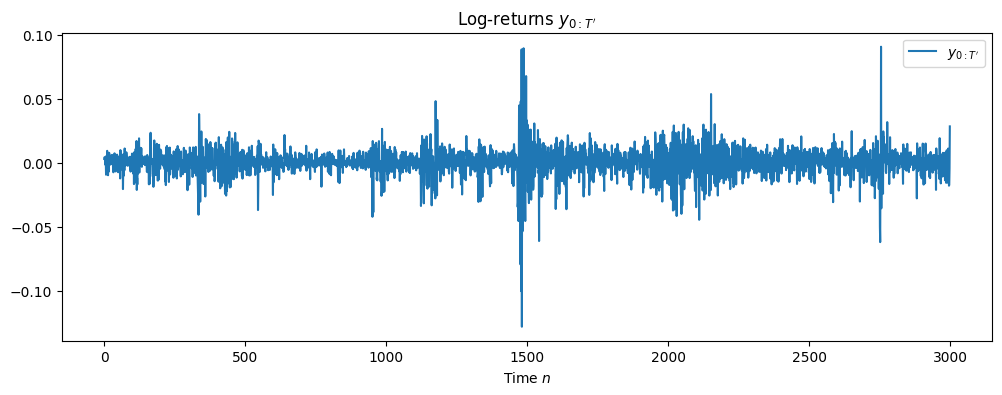

In [37]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(y_full, label=r"$y_{0:T'}$")
ax.legend()
ax.set_xlabel(r"Time $n$")
ax.set_title(r"Log-returns $y_{0:T'}$")
plt.show()

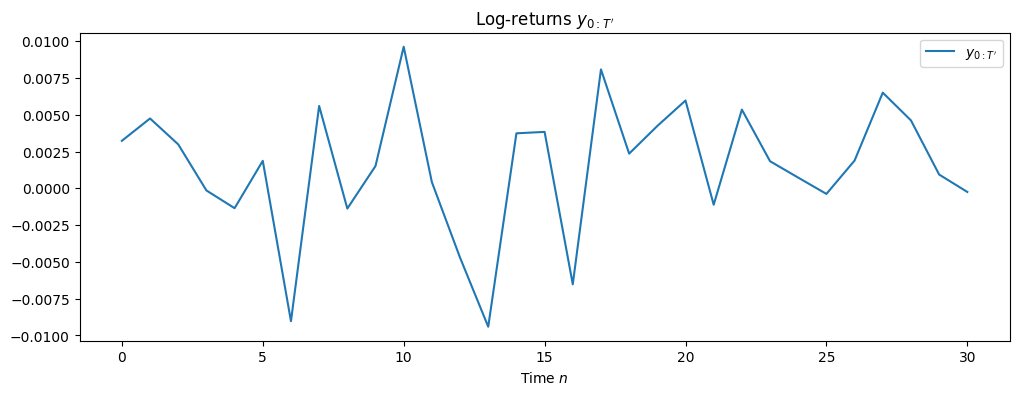

In [39]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(y, label=r"$y_{0:T'}$")
ax.legend()
ax.set_xlabel(r"Time $n$")
ax.set_title(r"Log-returns $y_{0:T'}$")
plt.show()

In [40]:
def f_rv(x_nm1, sigma, rho):
    return rho * x_nm1 + sigma * np.random.randn(len(x_nm1))

def f_pdf(x_n, x_nm1, sigma, rho):
    return scipy.stats.norm.pdf(x_n, loc=rho * x_nm1, scale=sigma)

def eta_rv(dim=1):
    return 0.1 * np.random.randn(dim)

def eta_pdf(x_0):
    return scipy.stats.norm.pdf(x_0, loc=0, scale=0.1)

def q_rv(x_nm1, sigma, rho):
    return f_rv(x_nm1, sigma, rho)

def q_pdf(x_n, x_nm1, sigma, rho):
    return f_pdf(x_n, x_nm1, sigma, rho)

def q0_rv(dim=1):
    return eta_rv(dim)

def q0_pdf(x_0):
    return eta_pdf(x_0)

def g_rv(x_n, beta):
    return beta * np.exp(x_n / 2) * np.random.randn(len(x_n))

def g_pdf(y_n, x_n, beta):
    return scipy.stats.norm.pdf(y_n, loc=0, scale=beta * np.exp(x_n / 2))

In [47]:
def incremental_weights0(X_0, y_0, beta):
    log_weights = scipy.stats.norm.logpdf(y_0, loc=0, scale=beta * np.exp(X_0 / 2))
    log_weights -= np.max(log_weights)  # subtract max for numerical stability
    weights = np.exp(log_weights)
    return weights


def incremental_weights(X_n, y_n, beta):
    log_weights = scipy.stats.norm.logpdf(y_n, loc=0, scale=beta * np.exp(X_n / 2))
    log_weights -= np.max(log_weights)
    weights = np.exp(log_weights)
    return weights


def SIR_samples_1(n, N, y, sigma, beta, rho, save_filtering_samples=False, save_each_path=False):
    if save_filtering_samples and save_each_path:
        raise AssertionError("CAN ONLY SPECIFY ONE OF save_filtering_samples AND save_each_path!")
    
    if save_filtering_samples:
        filtering_samples_dict = {}
    elif save_each_path:
        each_path_dict = {}

    sample_paths = np.zeros((N, n+1)) # each row represents a sample X^i_{0:n}
    
    # n = 0
    X0_samples = q0_rv(dim=N) # shape (N,)
    X0_weights = incremental_weights0(X0_samples, y[0], beta=beta)
    resample_idx = np.random.choice(N, size=N, p=X0_weights / np.sum(X0_weights)) # Re-sample indices with weights as probabilities
    X0_samples = X0_samples[resample_idx] # Select resampled particles
    sample_paths[:,0] = X0_samples # Fill in first column of sample paths

    if save_filtering_samples:
        filtering_samples_dict["0"] = X0_samples.copy()
    elif save_each_path:
        each_path_dict["0"] = X0_samples.reshape(-1, 1).copy()

    for k in range(1, n+1):
        Xkm1_samples = sample_paths[:, k-1]
        Xk_samples = q_rv(Xkm1_samples, sigma=sigma, rho=rho)
        sample_paths[:,k] = Xk_samples
        Xk_incremental_weights = incremental_weights(Xk_samples, y[k], beta=beta)
        resample_idx = np.random.choice(N, size=N, p=Xk_incremental_weights / np.sum(Xk_incremental_weights))
        # Re-sample paths
        sample_paths = sample_paths[resample_idx]
        if save_filtering_samples:
            filtering_samples_dict[f"{k}"] = sample_paths[:,k].copy()
        elif save_each_path:
            each_path_dict[f"{k}"] = sample_paths[:,:k+1].copy()

    if save_filtering_samples:
        return sample_paths, filtering_samples_dict
    elif save_each_path:
        return sample_paths, each_path_dict
    else:
        return sample_paths


def SIR_loglikelihood(n, N, y, sigma, beta, rho, return_one_final_marginal=False):
    sample_paths = np.zeros((N, n+1))

    X0_samples = q0_rv(dim=N)
    #log_w0 = np.array([scipy.stats.norm.logpdf(y[0], loc=0, scale=beta * np.exp(X0_samples[i]/2))
                       #for i in range(N)])
    log_w0 = scipy.stats.norm.logpdf(y[0], loc=0, scale=beta * np.exp(X0_samples/2))
    
    logllk = scipy.special.logsumexp(log_w0) - np.log(N)  # correct log mean
    
    # stabilised weights for resampling only
    w0 = np.exp(log_w0 - np.max(log_w0))
    resample_idx = np.random.choice(N, size=N, p=w0/np.sum(w0))
    X0_samples = X0_samples[resample_idx]
    sample_paths[:,0] = X0_samples

    for k in range(1, n+1):
        Xkm1_samples = sample_paths[:, k-1]
        Xk_samples = q_rv(Xkm1_samples, sigma=sigma, rho=rho)
        sample_paths[:,k] = Xk_samples
        #log_wk = np.array([scipy.stats.norm.logpdf(y[k], loc=0, scale=beta * np.exp(Xk_samples[i]/2))
                           #for i in range(N)])
        log_wk = scipy.stats.norm.logpdf(y[k], loc=0, scale=beta * np.exp(Xk_samples/2))
        logllk += scipy.special.logsumexp(log_wk) - np.log(N)
        
        wk = np.exp(log_wk - np.max(log_wk))
        resample_idx = np.random.choice(N, size=N, p=wk/np.sum(wk))
        sample_paths = sample_paths[resample_idx]

    if return_one_final_marginal:
        sample_idx = np.random.choice(N) # Sample a path uniformly
        final_marginal = sample_paths[sample_idx, -1]
        return logllk, final_marginal
    else:
        return logllk

In [48]:
sigma2_alpha = 2
sigma2_beta = 0.04
beta2_alpha = 2
beta2_beta = 2 * 2.5e-5
rho_lower = 0.8
rho_upper = 1


def prior_rv():
    sigma2 = scipy.stats.invgamma.rvs(a=sigma2_alpha, scale=sigma2_beta)
    beta2 = scipy.stats.invgamma.rvs(a=beta2_alpha,  scale=beta2_beta)
    rho = scipy.stats.uniform.rvs(loc=rho_lower, scale=rho_upper - rho_lower)
    return np.array([sigma2, beta2, rho])


def prior_logpdf(sigma2, beta2, rho):
    p_sigma2 = scipy.stats.invgamma.logpdf(sigma2, a=sigma2_alpha, scale=sigma2_beta)
    p_beta2  = scipy.stats.invgamma.logpdf(beta2,  a=beta2_alpha,  scale=beta2_beta)
    p_rho    = scipy.stats.uniform.logpdf(rho, loc=rho_lower, scale=rho_upper - rho_lower)
    return p_sigma2 + p_beta2 + p_rho


def prior_pdf(sigma2, beta2, rho):
    p_sigma2 = scipy.stats.invgamma.pdf(sigma2, a=sigma2_alpha, scale=sigma2_beta)
    p_beta2  = scipy.stats.invgamma.pdf(beta2,  a=beta2_alpha,  scale=beta2_beta)
    p_rho    = scipy.stats.uniform.pdf(rho, loc=rho_lower, scale=rho_upper - rho_lower)
    return p_sigma2 * p_beta2 * p_rho


def proposal_rv(theta_old, step_sizes=(0.01, 5e-6, 0.01)):
    """Theta is a np array of length 3"""
    step_sizes = np.array(step_sizes)
    return theta_old + step_sizes * np.random.randn(3)


def proposal_logpdf(theta_new, theta_old, step_sizes=(0.01, 5e-6, 0.01)):
    """Thetas are np arrays of length 3"""
    step_sizes = np.array(step_sizes)
    return scipy.stats.multivariate_normal.logpdf(theta_new, mean=theta_old, cov=np.diag(step_sizes**2))


In [49]:
def PMMH_step(theta_km1, loglikelihood_km1, xT_km1, N, step_sizes=(0.01, 5e-6, 0.01)):
    # Propose new sample
    theta_k = proposal_rv(theta_km1, step_sizes=step_sizes)
    sigma2_k, beta2_k, rho_k = theta_k
    # Reject if proposal is outside of prior bounds (otherwise the SIR will fail)
    if (sigma2_k <= 0) or (beta2_k <= 0) or (rho_k <= -1) or (rho_k >= 1):
        # Reject since proposal is outside prior bounds
        return theta_km1, loglikelihood_km1, xT_km1, 0
    # Compute log likelihood of proposed sample
    loglikelihood_k, xT_k = SIR_loglikelihood(T, N, y, sqrt(sigma2_k), sqrt(beta2_k), rho_k, return_one_final_marginal=True)
    # Compute acceptance probability
    sigma2_km1, beta2_km1, rho_km1 = theta_km1
    log_alpha = (
                loglikelihood_k + prior_logpdf(sigma2_k, beta2_k, rho_k)
              - loglikelihood_km1 - prior_logpdf(sigma2_km1, beta2_km1, rho_km1)
                )
    acceptance_prob = min(1, np.exp(log_alpha))
    if np.random.rand() < acceptance_prob:
        # Accept
        return theta_k, loglikelihood_k, xT_k, acceptance_prob
    else:
        # Reject
        return theta_km1, loglikelihood_km1, xT_km1, acceptance_prob

In [50]:
step_sizes = (0.01, 2e-6, 0.01)
theta_0 = np.array([0.04, 2.5e-5, 0.95])
N = 5000

if False:
    thetas = list(np.load(f"results/thetas_N{N}_stepsizes{step_sizes}_theta0{theta_0}.npy"))
    loglikelihoods = list(np.load(f"results/loglikelihoods_N{N}_stepsizes{step_sizes}_theta0{theta_0}.npy"))
    acceptance_ratios = list(np.load(f"results/acceptance_ratios_N{N}_stepsizes{step_sizes}_theta0{theta_0}.npy"))
    xTs = list(np.load(f"results/xTs_N{N}_stepsizes{step_sizes}_theta0{theta_0}.npy"))
#thetas = [list(theta) for theta in thetas]

In [77]:
num_iterations = 10000
step_sizes = (0.03, 4e-6, 0.03)
theta_0 = np.array([0.04, 2.5e-5, 0.95])
N = 1000
# Sample initial iterate from prior or define yourself
sigma2_0, beta2_0, rho_0 = theta_0
loglikelihood_0, xT_0 = SIR_loglikelihood(T, N, y, sqrt(sigma2_0), sqrt(beta2_0), rho_0, return_one_final_marginal=True)
# List to store iterates and log likelihoods
thetas = [theta_0]
loglikelihoods = [loglikelihood_0]
xTs = [xT_0]
acceptance_ratios = [0]

for k in range(len(thetas), len(thetas) + num_iterations):
    print(12*"-" + f"STEP {k}" + 12*"-")

    theta_km1 = thetas[k - 1]
    loglikelihood_km1 = loglikelihoods[k - 1]
    xT_km1 = xTs[k - 1]

    theta_k, loglikelihood_k, xT_k, acceptance_ratio_k = PMMH_step(theta_km1, loglikelihood_km1, xT_km1, N, step_sizes=step_sizes)

    thetas.append(theta_k)
    loglikelihoods.append(loglikelihood_k)
    acceptance_ratios.append(acceptance_ratio_k)
    xTs.append(xT_k)

    print(f"theta = {theta_k}, xT = {xT_k}")
    print(f"------------ cum_logllk_var = {np.var(loglikelihoods)}")
    print(f"------------ ar = {acceptance_ratio_k}, cum_mean_ar = {np.mean(acceptance_ratios)}")

------------STEP 1------------
theta = [2.88474094e-02 2.62648635e-05 9.31968907e-01], xT = -0.6510345167367391
------------ cum_logllk_var = 0.0023188453529359673
------------ ar = 1, cum_mean_ar = 0.5
------------STEP 2------------
theta = [2.88474094e-02 2.62648635e-05 9.31968907e-01], xT = -0.6510345167367391
------------ cum_logllk_var = 0.0020611958692764156
------------ ar = 0.07101245871879364, cum_mean_ar = 0.3570041529062646
------------STEP 3------------
theta = [2.88474094e-02 2.62648635e-05 9.31968907e-01], xT = -0.6510345167367391
------------ cum_logllk_var = 0.0017391340147019751
------------ ar = 0.0248906731066966, cum_mean_ar = 0.2739757829563726
------------STEP 4------------
theta = [2.31318497e-02 2.80030703e-05 9.61152713e-01], xT = -0.3813882543506658
------------ cum_logllk_var = 0.004199368133443751
------------ ar = 1, cum_mean_ar = 0.41918062636509806
------------STEP 5------------
theta = [2.31318497e-02 2.80030703e-05 9.61152713e-01], xT = -0.3813882543506

In [78]:
if False:
    np.save(f"results/thetas_N{N}_stepsizes{step_sizes}_theta0{theta_0}.npy", np.array(thetas))
    np.save(f"results/loglikelihoods_N{N}_stepsizes{step_sizes}_theta0{theta_0}.npy", loglikelihoods)
    np.save(f"results/acceptance_ratios_N{N}_stepsizes{step_sizes}_theta0{theta_0}.npy", acceptance_ratios)
    np.save(f"results/xTs_N{N}_stepsizes{step_sizes}_theta0{theta_0}.npy", xTs)

In [79]:
burn_in = 0
thetas_burnin = thetas[burn_in:]
loglikelihoods_burnin = loglikelihoods[burn_in:]
acceptance_ratios_burnin = acceptance_ratios[burn_in:]
xTs_burnin = xTs[burn_in:]

In [80]:
sigma2_samples = [theta[0] for theta in thetas_burnin]
beta2_samples = [theta[1] for theta in thetas_burnin]
rho_samples = [theta[2] for theta in thetas_burnin]

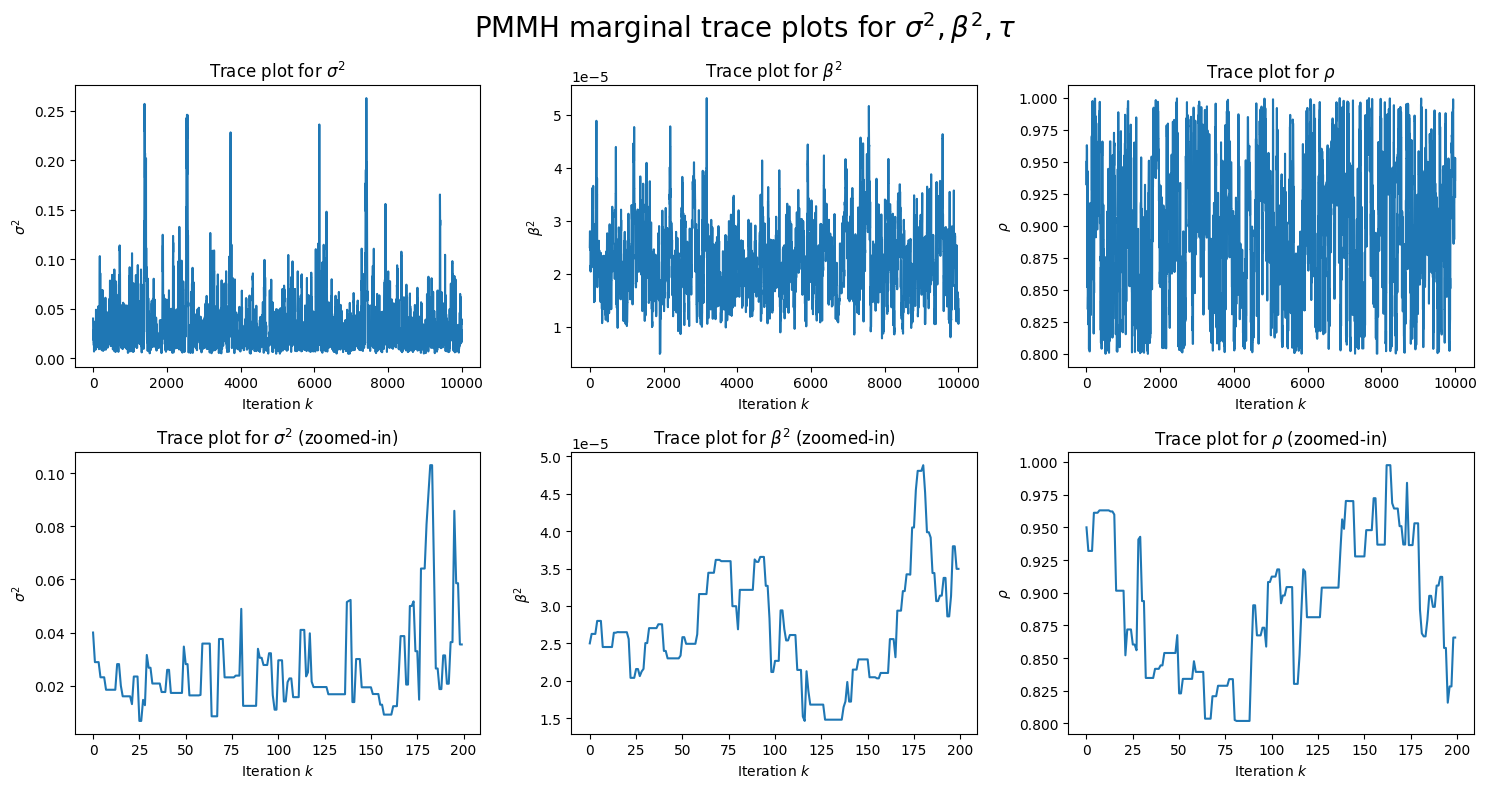

In [81]:
fig, ax = plt.subplots(figsize=(15,8), ncols=3, nrows=2)
num_zoomed_in = 200

ax[0,0].plot(sigma2_samples)
ax[0,0].set_xlabel(r"Iteration $k$")
ax[0,0].set_ylabel(r"$\sigma^2$")
ax[0,0].set_title(r"Trace plot for $\sigma^2$")

ax[1,0].plot(sigma2_samples[:num_zoomed_in])
ax[1,0].set_xlabel(r"Iteration $k$")
ax[1,0].set_ylabel(r"$\sigma^2$")
ax[1,0].set_title(r"Trace plot for $\sigma^2$ (zoomed-in)")

ax[0,1].plot(beta2_samples)
ax[0,1].set_xlabel(r"Iteration $k$")
ax[0,1].set_ylabel(r"$\beta^2$")
ax[0,1].set_title(r"Trace plot for $\beta^2$")

ax[1,1].plot(beta2_samples[:num_zoomed_in])
ax[1,1].set_xlabel(r"Iteration $k$")
ax[1,1].set_ylabel(r"$\beta^2$")
ax[1,1].set_title(r"Trace plot for $\beta^2$ (zoomed-in)")

ax[0,2].plot(rho_samples)
ax[0,2].set_xlabel(r"Iteration $k$")
ax[0,2].set_ylabel(r"$\rho$")
ax[0,2].set_title(r"Trace plot for $\rho$")

ax[1,2].plot(rho_samples[:num_zoomed_in])
ax[1,2].set_xlabel(r"Iteration $k$")
ax[1,2].set_ylabel(r"$\rho$")
ax[1,2].set_title(r"Trace plot for $\rho$ (zoomed-in)")

plt.suptitle(r"PMMH marginal trace plots for $\sigma^2, \beta^2, \tau$", fontsize=20)
plt.tight_layout()
plt.show()

ESS

CHAIN HEALTH DIAGNOSTICS

Parameter : $\sigma^2$
  Chain length  : 10001
  Unique values : 3635
  Mean          : 0.030773
  Std           : 0.028932
  ACF at lag-1  : 0.9217

Parameter : $\beta^2$
  Chain length  : 10001
  Unique values : 3635
  Mean          : 0.000022
  Std           : 0.000007
  ACF at lag-1  : 0.9461

Parameter : $\rho$
  Chain length  : 10001
  Unique values : 3635
  Mean          : 0.895799
  Std           : 0.054775
  ACF at lag-1  : 0.9528

FINAL ESS (full post-burnin chain)
   Parameter |  Chain length |  Final ESS |    ESS/n
-------------------------------------------------------
  $\sigma^2$ |         10001 |      298.3 |    0.030
   $\beta^2$ |         10001 |      266.1 |    0.027
      $\rho$ |         10001 |      227.0 |    0.023

Computing rolling ESS from n=350 to n=10001...
  $\sigma^2$ done — final rolling ESS: 298.3
  $\beta^2$ done — final rolling ESS: 266.1
  $\rho$ done — final rolling ESS: 227.0


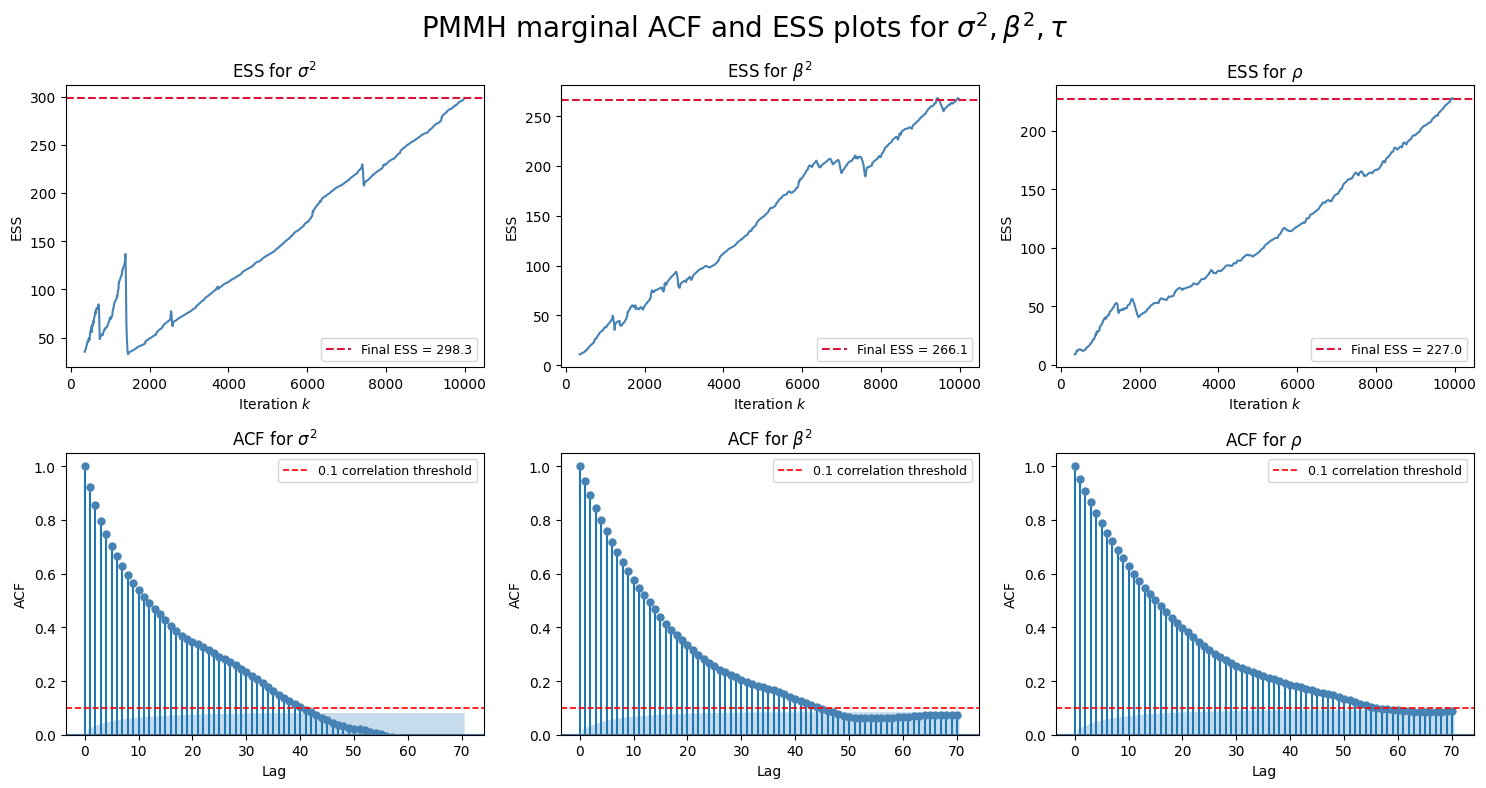

In [82]:

# ─────────────────────────────────────────────────────────────────
# 1. ROBUST ESS FUNCTION
# ─────────────────────────────────────────────────────────────────

def geyer_ess(samples, nlags=None):
    """
    Compute ESS using Geyer's truncation rule.

    - Excludes lag-0 from ACF sum
    - Truncates sum at first non-positive ACF value
    - Guards against degenerate (stuck) chains
    - Clips ESS to [1, n]

    Args:
        samples : 1D array-like of MCMC samples
        nlags   : number of ACF lags to compute (auto-selected if None)

    Returns:
        ess : float in [1, n]
    """
    samples = np.asarray(samples, dtype=float)
    n = len(samples)

    # ── Degenerate chain check ────────────────────────────────────
    if np.std(samples) < 1e-10:
        print("Warning: chain has near-zero variance (stuck chain) — ESS set to 1")
        return 1.0

    # ── Auto-select nlags if not provided ────────────────────────
    if nlags is None:
        nlags = min(10 * int(np.log10(max(n, 10))), n // 3)

    nlags = min(nlags, n - 1)   # cannot exceed chain length - 1

    # ── Compute ACF (lags 0, 1,..., nlags) ──────────────────────
    acf_vals = acf(samples, nlags=nlags, fft=True)

    # ── Geyer truncation: sum lags 1, 2,... until first non-positive ──
    rho_sum = 0.0
    for lag in range(1, len(acf_vals)):
        if acf_vals[lag] <= 0:
            break
        rho_sum += acf_vals[lag]

    # ── Guard against non-positive denominator ────────────────────
    denominator = 1.0 + 2.0 * rho_sum
    if denominator <= 0:
        return float(n)   # treat as independent samples

    ess = n / denominator
    return float(np.clip(ess, 1.0, float(n)))


# ─────────────────────────────────────────────────────────────────
# 2. SETUP — extract samples from posterior chain
# ─────────────────────────────────────────────────────────────────

# Assumes thetas_burnin is a list/array of shape (K, 3)
# with columns [sigma2, beta2, rho]
thetas_arr = np.array(thetas_burnin)   # shape (K, 3)

sigma2_samples = thetas_arr[:, 0]
beta2_samples  = thetas_arr[:, 1]
rho_samples    = thetas_arr[:, 2]

param_samples = {
    r"$\sigma^2$": sigma2_samples,
    r"$\beta^2$":  beta2_samples,
    r"$\rho$":     rho_samples,
}

# ─────────────────────────────────────────────────────────────────
# 3. CHAIN HEALTH DIAGNOSTICS
# ─────────────────────────────────────────────────────────────────

print("=" * 60)
print("CHAIN HEALTH DIAGNOSTICS")
print("=" * 60)
for name, samples in param_samples.items():
    n_unique = len(np.unique(samples))
    acf_lag1 = acf(samples, nlags=1, fft=True)[1]
    print(f"\nParameter : {name}")
    print(f"  Chain length  : {len(samples)}")
    print(f"  Unique values : {n_unique}")
    print(f"  Mean          : {np.mean(samples):.6f}")
    print(f"  Std           : {np.std(samples):.6f}")
    print(f"  ACF at lag-1  : {acf_lag1:.4f}")
    if n_unique < 10:
        print("  ⚠️  WARNING: very few unique values — chain may be stuck!")
    if acf_lag1 > 0.99:
        print("  ⚠️  WARNING: ACF lag-1 ≈ 1 — chain is not mixing!")

# ─────────────────────────────────────────────────────────────────
# 4. FINAL ESS (on full chain)
# ─────────────────────────────────────────────────────────────────

nlags = 70

print("\n" + "=" * 60)
print("FINAL ESS (full post-burnin chain)")
print("=" * 60)
print(f"{'Parameter':>12} | {'Chain length':>13} | {'Final ESS':>10} | {'ESS/n':>8}")
print("-" * 55)

final_ess = {}
for name, samples in param_samples.items():
    ess = geyer_ess(samples, nlags=nlags)
    final_ess[name] = ess
    n = len(samples)
    print(f"{name:>12} | {n:>13} | {ess:>10.1f} | {ess/n:>8.3f}")

# ─────────────────────────────────────────────────────────────────
# 5. ROLLING ESS (over growing windows)
# ─────────────────────────────────────────────────────────────────

total_num_iterations = len(thetas_burnin)

# Need enough samples for ACF to be reliable
# Rule of thumb: at least 5x nlags samples before computing ESS
min_samples = max(5 * nlags, 100)

# Single source of truth for x-axis and loop range
ess_n_values = list(range(min_samples, total_num_iterations + 1))
x_range      = ess_n_values   # guaranteed same length as ess_lists

print(f"\nComputing rolling ESS from n={min_samples} to n={total_num_iterations}...")

ess_lists = {name: [] for name in param_samples}
for name, samples in param_samples.items():
    for n in ess_n_values:
        ess_lists[name].append(geyer_ess(samples[:n], nlags=nlags))
    print(f"  {name} done — final rolling ESS: {ess_lists[name][-1]:.1f}")

# ── Sanity check lengths ──────────────────────────────────────────
for name in param_samples:
    assert len(x_range) == len(ess_lists[name]), \
        f"Length mismatch for {name}: x={len(x_range)}, y={len(ess_lists[name])}"

# ─────────────────────────────────────────────────────────────────
# 6. PLOTS: Rolling ESS + ACF
# ─────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(15, 8), nrows=2, ncols=3)

for col, (name, samples) in enumerate(param_samples.items()):

    # ── Row 0: Rolling ESS ───────────────────────────────────────
    ax[0, col].plot(x_range, ess_lists[name], color='steelblue', linewidth=1.5)
    ax[0, col].axhline(
        final_ess[name],
        color='crimson', linestyle='--', linewidth=1.5,
        label=f"Final ESS = {final_ess[name]:.1f}"
    )
    ax[0, col].set_title(f"ESS for {name}")
    ax[0, col].set_ylabel("ESS")
    ax[0, col].set_xlabel(r"Iteration $k$")
    ax[0, col].legend(fontsize=9)

    # ── Row 1: ACF ───────────────────────────────────────────────
    plot_acf(samples, lags=nlags, ax=ax[1, col], color='steelblue')
    ax[1, col].set_title(f"ACF for {name}")
    ax[1, col].set_ylabel("ACF")
    ax[1, col].set_xlabel("Lag")
    ax[1, col].set_ylim((0, 1.05))
    ax[1, col].axhline(
        0.0,  color='black',  linestyle='-',  linewidth=0.8
    )
    ax[1, col].axhline(
        0.1,  color='red',    linestyle='--', linewidth=1.2,
        label="0.1 correlation threshold"
    )
    ax[1, col].legend(fontsize=9)

plt.suptitle(r"PMMH marginal ACF and ESS plots for $\sigma^2, \beta^2, \tau$", fontsize=20)
plt.tight_layout()
plt.show()

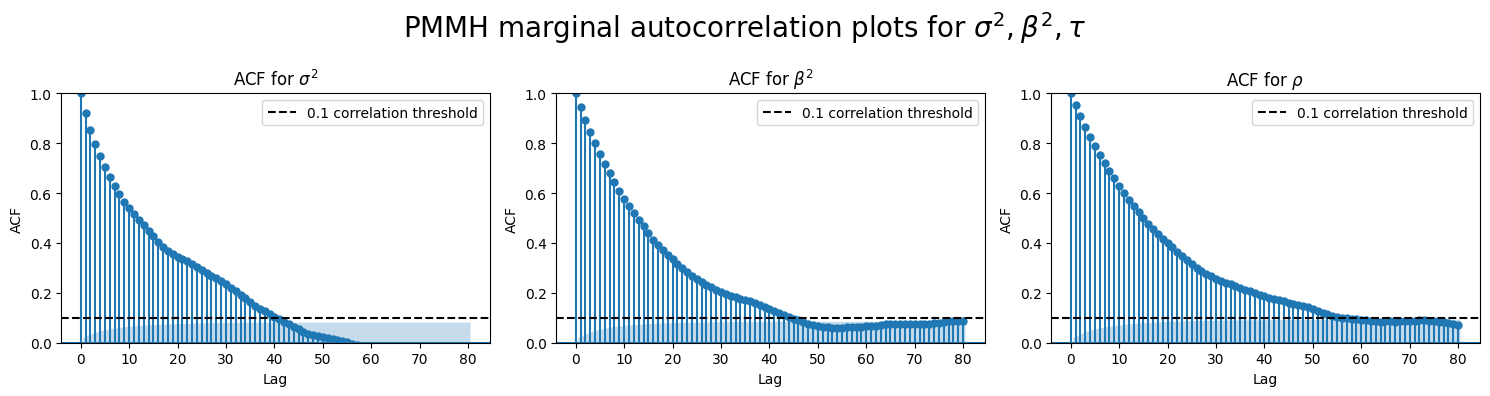

In [83]:
fig, ax = plt.subplots(figsize=(15,4), ncols=3)

nlags=80

plot_acf(sigma2_samples, lags=nlags, ax=ax[0])
ax[0].set_title(r"ACF for $\sigma^2$")
ax[0].set_ylabel("ACF")
ax[0].set_xlabel("Lag")
ax[0].set_ylim((0, 1))
ax[0].axhline(0.1, linestyle="--", color="k", label="0.1 correlation threshold")
ax[0].legend()

plot_acf(beta2_samples, lags=nlags, ax=ax[1])
ax[1].set_title(r"ACF for $\beta^2$")
ax[1].set_ylabel(r"ACF")
ax[1].set_xlabel("Lag")
ax[1].set_ylim((0, 1))
ax[1].axhline(0.1, linestyle="--", color="k", label="0.1 correlation threshold")
ax[1].legend()

plot_acf(rho_samples, lags=nlags, ax=ax[2])
ax[2].set_title(r"ACF for $\rho$")
ax[2].set_ylabel(r"ACF")
ax[2].set_xlabel("Lag")
ax[2].set_ylim((0, 1))
ax[2].axhline(0.1, linestyle="--", color="k", label="0.1 correlation threshold")
ax[2].legend()

plt.suptitle(r"PMMH marginal autocorrelation plots for $\sigma^2, \beta^2, \tau$", fontsize=20)
plt.tight_layout()
plt.show()

Marginals

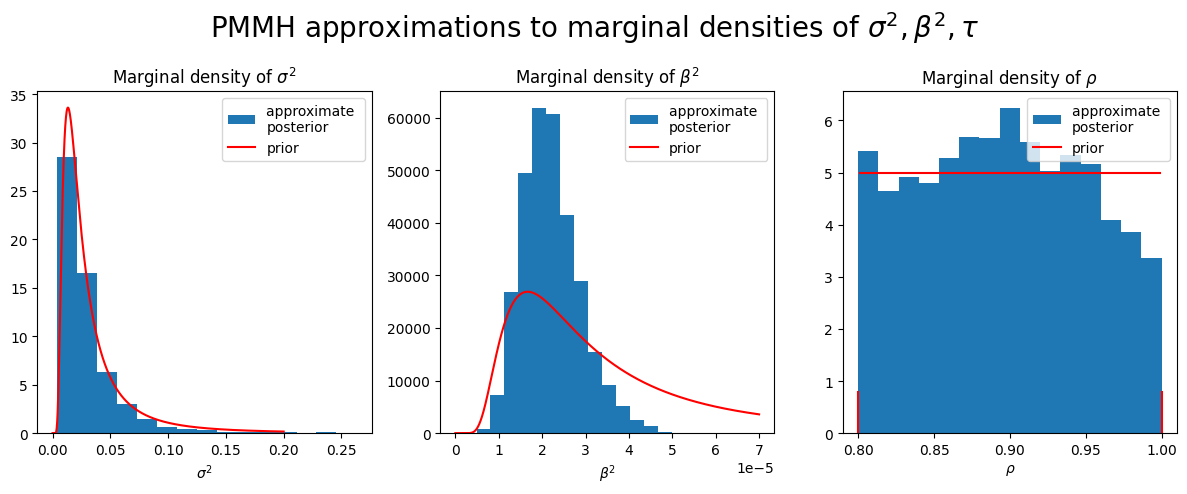

In [84]:
fig, ax = plt.subplots(figsize=(12,5), ncols=3)
bins=15

ax[0].hist([theta[0] for theta in thetas_burnin], bins=bins, density=True, label="approximate \nposterior")
ax[0].set_xlabel(r"$\sigma^2$")
ax[0].set_title(r"Marginal density of $\sigma^2$")
ax[0].plot(np.linspace(0.0000000001,0.2,1000), 
           scipy.stats.invgamma.pdf(np.linspace(0.0000000001,0.2,1000), a=sigma2_alpha, scale=sigma2_beta),
           color="red", label=r"prior")
ax[0].legend()

ax[1].hist([theta[1] for theta in thetas_burnin], bins=bins, density=True, label="approximate \nposterior")
ax[1].set_xlabel(r"$\beta^2$")
ax[1].set_title(r"Marginal density of $\beta^2$")
ax[1].plot(np.linspace(0.0000000000001,7e-5,1000), 
           scipy.stats.invgamma.pdf(np.linspace(0.0000000000001,7e-5,1000), a=beta2_alpha, scale=beta2_beta),
           color="red", label=r"prior")
ax[1].legend()

ax[2].hist([theta[2] for theta in thetas_burnin], bins=bins, density=True, label="approximate \nposterior")
ax[2].set_xlabel(r"$\rho$")
ax[2].set_title(r"Marginal density of $\rho$")
ax[2].axhline(5, color="red", xmin=0.05, xmax=0.95, label=r"prior")
ax[2].axvline(1, color="red", ymax=0.12)
ax[2].axvline(0.8, color="red", ymax=0.12)

ax[2].set_xlim(0.79, 1.01)
ax[2].legend()

plt.suptitle(r"PMMH approximations to marginal densities of $\sigma^2, \beta^2, \tau$", fontsize=20)
plt.tight_layout()
plt.show()

Posterior predictive

In [59]:
# Extend latent trajectory to T+1,...,T' for each of the K+1 samples (after burn-in)
K = len(thetas) - 1 - burn_in
x_Tp1_to_T_prime = np.zeros((K+1, T_prime - T))
for k in range(K+1):
    xT_k = xTs_burnin[k]
    x_T_to_T_prime_k = [xT_k]
    sigma2_k, beta2_k, rho_k = thetas_burnin[k]
    for i in range(1, T_prime - T + 1):
        x_jm1 = x_T_to_T_prime_k[i - 1]
        xj_k = rho_k * x_jm1 + sqrt(sigma2_k) * np.random.randn()
        x_T_to_T_prime_k.append(xj_k)
    x_Tp1_to_T_prime_k = x_T_to_T_prime_k[1:]
    x_Tp1_to_T_prime[k, :] = x_Tp1_to_T_prime_k

In [60]:
def posterior_predictive_sample(thetas_burnin, x_Tp1_to_T_prime):
    """Single sample"""
    K = len(thetas_burnin)
    k = np.random.choice(K) # Mixture idx
    sigma2_k, beta2_k, rho_k = thetas_burnin[k]
    x_Tp1_to_T_prime_k = x_Tp1_to_T_prime[k, :]
    y_Tp1_to_T_prime = sqrt(beta2_k) * np.exp(x_Tp1_to_T_prime_k / 2) * np.random.randn(T_prime - T)
    return y_Tp1_to_T_prime # Shape (T_prime - T, )


def posterior_predictive_samples(thetas_burnin, x_Tp1_to_T_prime, num_samples):
    """Multiple samples"""
    y_Tp1_to_T_prime_samples = np.zeros((num_samples, T_prime - T))
    for samp in range(num_samples):
        y_Tp1_to_T_prime_ = posterior_predictive_sample(thetas_burnin, x_Tp1_to_T_prime)
        y_Tp1_to_T_prime_samples[samp, :] = y_Tp1_to_T_prime_
    return y_Tp1_to_T_prime_samples # Shape (num_samples, T_prime - T)

In [61]:
y_Tp1_to_T_prime_samples = posterior_predictive_samples(thetas_burnin, x_Tp1_to_T_prime, num_samples=10000)

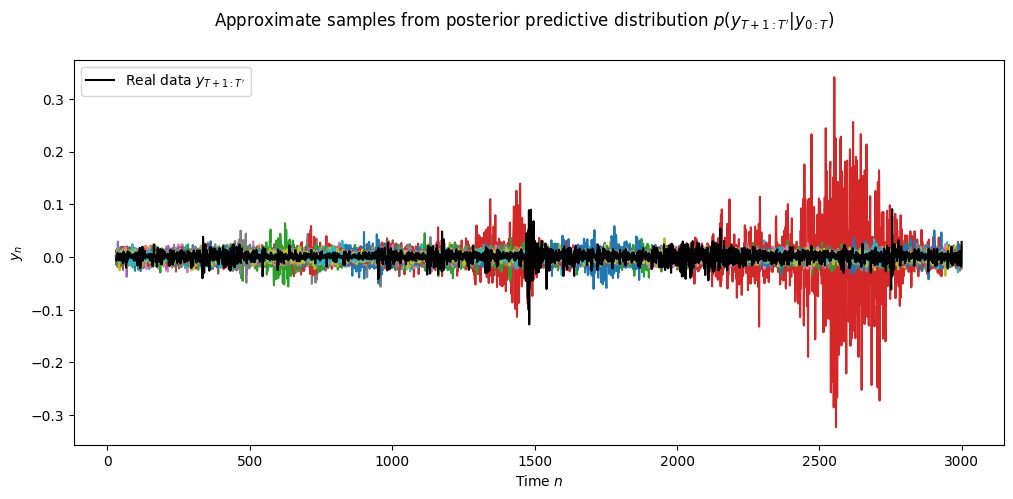

In [62]:
fig, ax = plt.subplots(figsize=(12,5))
num_samples_to_plot = 100
ax.plot(range(T+1,T_prime+1), y_Tp1_to_T_prime_samples[:num_samples_to_plot].T)
ax.plot(range(T+1,T_prime+1), y_full[T+1:], color="k", label=r"Real data $y_{T+1:T'}$")
ax.set_xlabel(r"Time $n$")
ax.set_ylabel(r"$y_n$")
ax.legend()
plt.suptitle(r"Approximate samples from posterior predictive distribution $p(y_{T+1:T'}|y_{0:T})$")
plt.show()

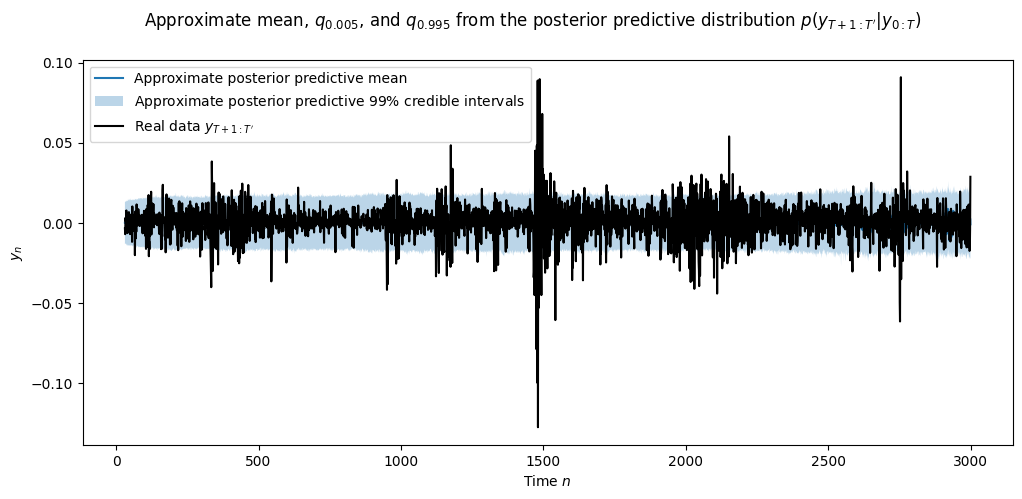

In [63]:
mean_y_Tp1_to_T_prime = np.mean(y_Tp1_to_T_prime_samples, axis=0)
qlower_y_Tp1_to_T_prime = np.quantile(y_Tp1_to_T_prime_samples, q=0.005, axis=0)
qupper_y_Tp1_to_T_prime = np.quantile(y_Tp1_to_T_prime_samples, q=1 - 0.005, axis=0)

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(range(T+1,T_prime+1), mean_y_Tp1_to_T_prime, label=r"Approximate posterior predictive mean")
ax.fill_between(range(T+1,T_prime+1),
                qlower_y_Tp1_to_T_prime,
                qupper_y_Tp1_to_T_prime,
                alpha=0.3,
                label=r"Approximate posterior predictive $99\%$ credible intervals")
ax.plot(range(T+1,T_prime+1), y_full[T+1:], color="k", label=r"Real data $y_{T+1:T'}$")
ax.set_xlabel(r"Time $n$")
ax.set_ylabel(r"$y_n$")
ax.legend()
plt.suptitle(r"Approximate mean, $q_{0.005}$, and $q_{0.995}$ from the posterior predictive distribution $p(y_{T+1:T'}|y_{0:T})$")
plt.show()


$p(y_{0:T})$ sampler (for testing):

In [71]:
def sample_yT(thetas_burnin, xTs_burnin):
    """Single sample"""
    K = len(thetas_burnin)
    k = np.random.choice(K) # Mixture idx
    sigma2_k, beta2_k, rho_k = thetas_burnin[k]
    xT_k = xTs_burnin[k]
    yT = sqrt(beta2_k) * np.exp(xT_k / 2) * np.random.randn()
    return yT


def samples_yT(thetas_burnin, xTs_burnin, num_samples):
    """Multiple samples"""
    yTs = []
    for samp in range(num_samples):
        yT_ = sample_yT(thetas_burnin, xTs_burnin)
        yTs.append(yT_)
    return np.array(yTs)

In [72]:
yTs = samples_yT(thetas_burnin, xTs_burnin, 10000)
np.quantile(yTs, q=0.005), np.mean(yTs) , np.quantile(yTs, q=1 - 0.005)

(np.float64(-0.015864746417665197),
 np.float64(-2.4273579506628898e-05),
 np.float64(0.015459092437312505))

Synthetic data for testing

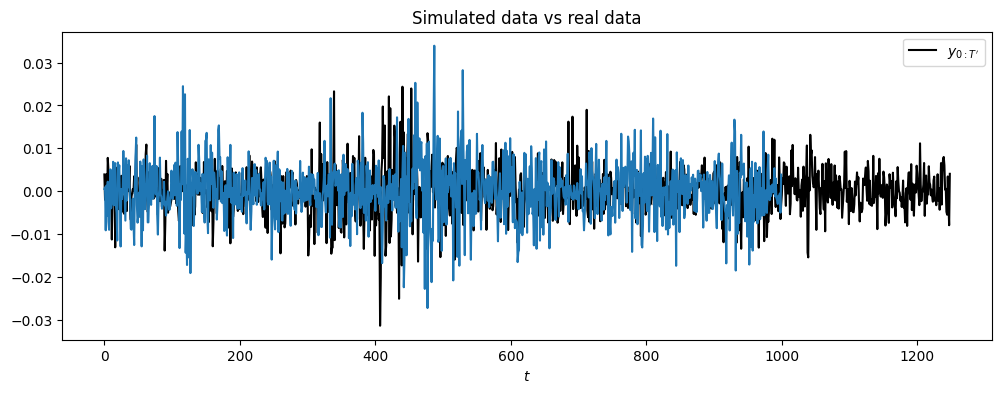

In [24]:
sigma_true = 0.2
sigma2_true = sigma_true**2
rho_true = 0.975
beta_true = sqrt(3e-5)
beta2_true = beta_true**2

def generate_x(T):
    xs = []
    for k in range(T+1):
        # Compute x_k
        if k==0:
            x = scipy.stats.norm.rvs(loc=0, scale=sqrt(0.01))
        else:
            X_km1 = xs[k-1]
            x = scipy.stats.norm.rvs(loc=rho_true * X_km1, scale=sigma_true)
        # Append state to trajectory
        xs.append(x)
    return np.array(xs)

def generate_y(xs):
    ys = []
    for xk in xs:
        yk = scipy.stats.norm.rvs(loc=0, scale=beta_true * np.exp(xk/2))
        ys.append(yk)
    return ys


x_sim = generate_x(T)
y_sim = generate_y(x_sim)

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(data, label=r"$y_{0:T'}$", color="k")
ax.plot(y_sim)

ax.legend()
ax.set_xlabel(r"$t$")
ax.set_title(r"Simulated data vs real data")
plt.show()

In [19]:
sd_of_y = np.std(y)
print(f"Standard deviation of dataset is {sd_of_y}")

Standard deviation of dataset is 0.005537578771734292


In [20]:
def approximate_sd_of_y(sigma, beta, rho):
    return beta * np.exp(0.25 * sigma**2 / (1 - rho))

def beta_to_target_sd(sigma, rho, target_sd):
    return target_sd / np.exp(0.25 * sigma**2 / (1 - rho))

In [29]:
approximate_sd_of_y(sqrt(0.03), sqrt(2.5e-5), 0.98) * 3

np.float64(0.021824871219273012)

In [32]:
np.mean(xTs_burnin)

np.float64(0.2454868640850468)

In [33]:
sqrt(2.5e-5) * np.exp(0.25/2)

np.float64(0.005665742265334132)